[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Continuous beam with two spans: refine a member into multiple elements

Last updated: 07/11/26

## Problem description

Variation on  02_continuous_beam_2_spans_consist_tut.py. The member 2 is
**refined** into three members automatically.

## References

Introductory example 7.1 from Structural Mechanics. Analytical and Numerical
Approaches for Structural Analysis by Lingyi Lu, Junbo Jia, Zhuo Tang.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [1]:
import scipy
from numpy import dot
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots

Create a two dimensional (planar) model.


In [2]:
m = model.create(2)
freedoms = m["freedoms"]

There are three joints.


In [3]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [5.0, 0.0])
model.add_joint(m, 3, [12.0, 0.0])

The supports are added to the model. The pinned supports are added to the
joint by listing the degree of freedom designations, `freedoms.U1` and
`freedoms.U2`. These degrees of freedom are suppressed (set to zero). Note that
each of the joints also has a rotation degree of freedom, `freedoms.UR3`, which
are free at all joints.


In [4]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2)
model.add_support(m["joints"][2], freedoms.U1)
model.add_support(m["joints"][2], freedoms.U2)
model.add_support(m["joints"][3], freedoms.U1)
model.add_support(m["joints"][3], freedoms.U2)

The beam members have different material properties and cross sectional
properties. We create two separate sections for the two beam members.


In [5]:
E = 3e10
A = 0.001
I = 1.44e-5
s1 = section.beam_2d_section("section_1", E, A, I)
model.add_beam_member(m, 1, [1, 2], s1)
E = 2.06e11
A = 0.001
I = 1.152e-5
s2 = section.beam_2d_section("section_2", E, A, I)
model.add_beam_member(m, 2, [2, 3], s2)

Let's have a look at the model before it is refined.


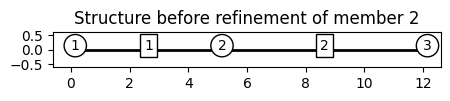

In [6]:
plots.setup(m, set_limits=True)
plots.plot_members(m)
plots.plot_member_ids(m)
ax = plots.plot_joint_ids(m)
ax.set_title("Structure before refinement of member 2")
plots.show(m)

The member 2 is refined into three members. The model is updated with new
joints ant members. The old member 2 is removed.


In [7]:
model.refine_member(m, 2, 3)

The model is shown after the refinement.


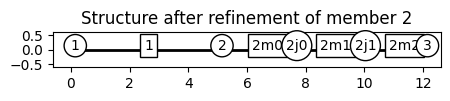

In [8]:
plots.setup(m, set_limits=True)
plots.plot_members(m)
plots.plot_member_ids(m)
ax = plots.plot_joint_ids(m)
ax.set_title("Structure after refinement of member 2")
plots.show(m)

Next we add the loads and solve the model.|

In [9]:
# The loads are  moments at the joints.
model.add_load(m["joints"][1], freedoms.UR3, -15e3)
model.add_load(m["joints"][2], freedoms.UR3, -25e3)
model.add_load(m["joints"][3], freedoms.UR3, +35e3)

The model is solved.


In [10]:
model.number_dofs(m)
model.solve_statics(m)

These displacements can be compared with the reference values from literature.


In [11]:
if norm(m["U"][0:3] - [-0.02969075, -0.02742406, 0.03952194]) > 1.0e-3:
    raise ValueError("Displacement calculation error")
print("Displacement calculation OK")

Displacement calculation OK


The displacements can be seen to be the same as in  `02_continuous_beam_2_spans_consist_tut.ipynb`.
The deformed shape shows the curvatures of the beam.


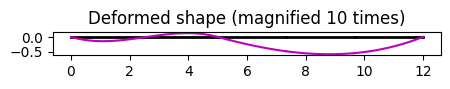

In [12]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 10.0)
ax.set_title("Deformed shape (magnified 10 times)")
plots.show(m)

And the internal forces too. The bending moment:


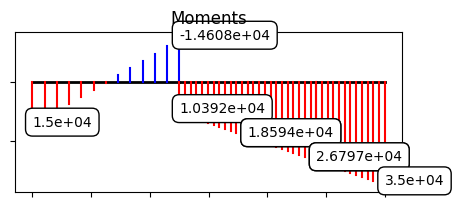

In [13]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m, scale=0.0001)
ax.set_title("Moments")
plots.show(m)

The shear forces:


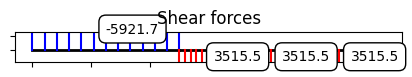

In [14]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_shear_forces(m, scale=0.0001)
ax.set_title("Shear forces")
plots.show(m)

## Conclusions

Individual members can be profitably refined into multiple finite elements.